# META — Short Mejorado: salida específica para RUPTURA (V2)

Esta variante conserva todas las entradas LONG y SHORT del algoritmo original. Solo modifica la salida de los shorts abiertos por **RUPTURA**.

- `SHORT RSI > 70`: conserva la salida original `RSI < 50`.
- `SHORT RUPTURA`: sale por stop inicial del 7 %, trailing de 2 ATR, dos cierres sobre EMA10, RSI > 55 o un máximo de 20 sesiones.
- Si llega otra entrada original antes de cerrar una ruptura, la ruptura se cierra en esa apertura y la entrada original tiene prioridad.

El cuaderno compara Original contra V2 en 3, 6, 9, 12, 15 y 18 meses, audita que todas las entradas sean idénticas y muestra únicamente el gráfico comparativo de 9 meses.

In [1]:
# Si fuera necesario: %pip install -q yfinance python-dateutil matplotlib pandas numpy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython import get_ipython
from IPython.display import display
from dateutil.relativedelta import relativedelta
warnings.filterwarnings('ignore')
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

TICKER = 'META'
CAPITAL_INICIAL = 10_000
VENTANAS = [3, 6, 9, 12, 15, 18]
STOP_LONG = 0.07
STOP_SHORT = 0.07
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
RUPTURA_ATR = 2.0
RUPTURA_MAX_SESIONES = 20

datos = yf.download(TICKER, period='5y', interval='1d', auto_adjust=False, progress=False)
if datos.empty:
    raise RuntimeError('No se pudieron descargar datos de META.')
if isinstance(datos.columns, pd.MultiIndex):
    datos.columns = datos.columns.get_level_values(0)
datos = datos[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()
print(f'Datos: {datos.index.min().date()} → {datos.index.max().date()} | {len(datos)} sesiones')

Datos: 2021-08-23 → 2026-08-21 | 1255 sesiones


In [2]:
def preparar_senales(df):
    d = df.copy()
    delta = d['Close'].diff()
    subida, bajada = delta.clip(lower=0), -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)
    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desv = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desv
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()
    cierre_previo = d['Close'].shift(1)
    tr = pd.concat([d['High'] - d['Low'], (d['High'] - cierre_previo).abs(),
                    (d['Low'] - cierre_previo).abs()], axis=1).max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()
    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOLUMEN_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = (d['Close'] < d['MINIMO_20_PREV']) & \
                         (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    d['SHORT_ENTRY'] = d['SHORT_RSI'] | d['SHORT_RUPTURA']
    d['SHORT_EXIT'] = d['RSI'] < 50
    return d

datos = preparar_senales(datos)

In [3]:
def ejecutar_original(df):
    d, capital = df.copy(), float(CAPITAL_INICIAL)
    posicion = precio_entrada = fecha_entrada = sistema = None
    operaciones, equity = [], []
    for i in range(1, len(d)):
        fecha, fila, senal = d.index[i], d.iloc[i], d.iloc[i-1]
        apertura, maximo, minimo, cierre = map(float, [fila['Open'], fila['High'], fila['Low'], fila['Close']])
        if posicion is None:
            if bool(senal['LONG_ENTRY']):
                posicion, sistema, precio_entrada, fecha_entrada = 'LONG', 'RSI + BOLLINGER', apertura, fecha
            elif bool(senal['SHORT_ENTRY']):
                sistema = 'RUPTURA' if bool(senal['SHORT_RUPTURA']) else 'RSI > 70'
                posicion, precio_entrada, fecha_entrada = 'SHORT', apertura, fecha
        elif posicion == 'LONG':
            stop, salida, motivo = precio_entrada * (1 - STOP_LONG), None, None
            if minimo <= stop: salida, motivo = stop, 'STOP LOSS LONG'
            elif bool(senal['LONG_EXIT']): salida, motivo = apertura, 'SEÑAL SALIDA LONG'
            if salida is not None:
                retorno = (salida - precio_entrada) / precio_entrada; capital *= 1 + retorno
                operaciones.append({'Tipo':'LONG','Sistema entrada':sistema,'Entrada':fecha_entrada,
                    'Precio entrada':precio_entrada,'Salida':fecha,'Precio salida':salida,
                    'Rentabilidad %':retorno*100,'Motivo':motivo})
                posicion = precio_entrada = fecha_entrada = sistema = None
        elif posicion == 'SHORT':
            stop, salida, motivo = precio_entrada * (1 + STOP_SHORT), None, None
            if maximo >= stop: salida, motivo = stop, 'STOP LOSS SHORT'
            elif bool(senal['SHORT_EXIT']): salida, motivo = apertura, 'SEÑAL SALIDA SHORT'
            if salida is not None:
                retorno = (precio_entrada - salida) / precio_entrada; capital *= 1 + retorno
                operaciones.append({'Tipo':'SHORT','Sistema entrada':sistema,'Entrada':fecha_entrada,
                    'Precio entrada':precio_entrada,'Salida':fecha,'Precio salida':salida,
                    'Rentabilidad %':retorno*100,'Motivo':motivo})
                posicion = precio_entrada = fecha_entrada = sistema = None
        if posicion == 'LONG': valor = capital * (1 + (cierre-precio_entrada)/precio_entrada)
        elif posicion == 'SHORT': valor = capital * (1 + (precio_entrada-cierre)/precio_entrada)
        else: valor = capital
        equity.append({'Fecha':fecha,'Equity':valor})
    if posicion is not None:
        salida, fecha = float(d['Close'].iloc[-1]), d.index[-1]
        retorno = ((salida-precio_entrada)/precio_entrada if posicion=='LONG' else (precio_entrada-salida)/precio_entrada)
        capital *= 1 + retorno
        operaciones.append({'Tipo':posicion,'Sistema entrada':sistema,'Entrada':fecha_entrada,
            'Precio entrada':precio_entrada,'Salida':fecha,'Precio salida':salida,
            'Rentabilidad %':retorno*100,'Motivo':'FIN DEL PERIODO'})
        equity[-1]['Equity'] = capital
    eq = pd.DataFrame(equity).set_index('Fecha')
    dd = (eq['Equity']/eq['Equity'].cummax()-1).min()*100
    return {'Capital final':capital,'Rentabilidad %':(capital/CAPITAL_INICIAL-1)*100,
            'Drawdown máximo %':dd,'Operaciones':operaciones,'Equity':eq}


In [4]:
def ejecutar_v2(df, operaciones_originales):
    d, capital = df.copy(), float(CAPITAL_INICIAL)
    # Calendario causal de las entradas que el original ejecutó. V2 no añade ni elimina entradas.
    entradas = {op['Entrada']: op for op in operaciones_originales}
    posicion = precio_entrada = fecha_entrada = sistema = None
    operaciones, equity = [], []
    minimo_desde_entrada, trailing, sesiones = np.inf, np.inf, 0

    def abrir(op, fecha, apertura):
        nonlocal posicion, precio_entrada, fecha_entrada, sistema, minimo_desde_entrada, trailing, sesiones
        posicion, sistema = op['Tipo'], op['Sistema entrada']
        precio_entrada, fecha_entrada = apertura, fecha
        minimo_desde_entrada, trailing, sesiones = apertura, apertura*(1+STOP_SHORT), 0

    def cerrar(fecha, salida, motivo):
        nonlocal capital, posicion, precio_entrada, fecha_entrada, sistema
        retorno = ((salida-precio_entrada)/precio_entrada if posicion=='LONG' else (precio_entrada-salida)/precio_entrada)
        capital *= 1 + retorno
        operaciones.append({'Tipo':posicion,'Sistema entrada':sistema,'Entrada':fecha_entrada,
            'Precio entrada':precio_entrada,'Salida':fecha,'Precio salida':salida,
            'Rentabilidad %':retorno*100,'Motivo':motivo})
        posicion = precio_entrada = fecha_entrada = sistema = None

    for i in range(1, len(d)):
        fecha, fila, senal = d.index[i], d.iloc[i], d.iloc[i-1]
        apertura, maximo, minimo, cierre = map(float, [fila['Open'],fila['High'],fila['Low'],fila['Close']])
        entrada_programada = entradas.get(fecha)
        # Toda entrada original posterior tiene prioridad sobre una ruptura prolongada.
        if entrada_programada is not None and posicion is not None:
            cerrar(fecha, apertura, 'PRIORIDAD A NUEVA ENTRADA ORIGINAL')
        if entrada_programada is not None and posicion is None:
            abrir(entrada_programada, fecha, apertura)
        elif posicion == 'LONG':
            stop = precio_entrada*(1-STOP_LONG)
            if minimo <= stop: cerrar(fecha, stop, 'STOP LOSS LONG')
            elif bool(senal['LONG_EXIT']): cerrar(fecha, apertura, 'SEÑAL SALIDA LONG')
        elif posicion == 'SHORT' and sistema != 'RUPTURA':
            stop = precio_entrada*(1+STOP_SHORT)
            if maximo >= stop: cerrar(fecha, stop, 'STOP LOSS SHORT')
            elif bool(senal['SHORT_EXIT']): cerrar(fecha, apertura, 'SEÑAL SALIDA SHORT')
        elif posicion == 'SHORT' and sistema == 'RUPTURA':
            sesiones += 1
            stop_activo = min(precio_entrada*(1+STOP_SHORT), trailing)
            recupera_ema = i >= 2 and bool((d['Close'].iloc[i-2:i] > d['EMA10'].iloc[i-2:i]).all())
            if maximo >= stop_activo: cerrar(fecha, stop_activo, 'STOP/TRAILING RUPTURA')
            elif recupera_ema: cerrar(fecha, apertura, 'DOS CIERRES SOBRE EMA10')
            elif bool(senal['RSI'] > 55): cerrar(fecha, apertura, 'RSI > 55')
            elif sesiones >= RUPTURA_MAX_SESIONES: cerrar(fecha, apertura, 'MÁXIMO 20 SESIONES')
            else:
                minimo_desde_entrada = min(minimo_desde_entrada, cierre)
                if pd.notna(fila['ATR14']): trailing = min(trailing, minimo_desde_entrada + RUPTURA_ATR*float(fila['ATR14']))
        if posicion == 'LONG': valor = capital*(1+(cierre-precio_entrada)/precio_entrada)
        elif posicion == 'SHORT': valor = capital*(1+(precio_entrada-cierre)/precio_entrada)
        else: valor = capital
        equity.append({'Fecha':fecha,'Equity':valor})
    if posicion is not None:
        cerrar(d.index[-1], float(d['Close'].iloc[-1]), 'FIN DEL PERIODO')
        equity[-1]['Equity'] = capital
    eq = pd.DataFrame(equity).set_index('Fecha')
    dd = (eq['Equity']/eq['Equity'].cummax()-1).min()*100
    return {'Capital final':capital,'Rentabilidad %':(capital/CAPITAL_INICIAL-1)*100,
            'Drawdown máximo %':dd,'Operaciones':operaciones,'Equity':eq}


In [5]:
def firma_entradas(ops):
    return [(o['Tipo'],o['Sistema entrada'],o['Entrada'],round(o['Precio entrada'],6)) for o in ops]

resultados, filas = {}, []
for meses in VENTANAS:
    periodo = datos.loc[datos.index >= datos.index[-1]-relativedelta(months=meses)].copy()
    original = ejecutar_original(periodo)
    v2 = ejecutar_v2(periodo, original['Operaciones'])
    assert firma_entradas(original['Operaciones']) == firma_entradas(v2['Operaciones']), \
        f'V2 ha alterado alguna entrada original en {meses} meses.'
    resultados[meses] = {'datos':periodo,'Original':original,'V2':v2}
    for nombre,r in [('Original',original),('V2 salida ruptura',v2)]:
        rupturas=[o for o in r['Operaciones'] if o['Sistema entrada']=='RUPTURA']
        filas.append({'Ventana':meses,'Estrategia':nombre,'Capital final':r['Capital final'],
            'Rentabilidad %':r['Rentabilidad %'],'Drawdown máximo %':r['Drawdown máximo %'],
            'Operaciones':len(r['Operaciones']),'Rentabilidad rupturas %':sum(o['Rentabilidad %'] for o in rupturas)})
tabla = pd.DataFrame(filas)
print('AUDITORÍA SUPERADA: todas las entradas LONG y SHORT originales son idénticas.')
display(tabla.style.format({'Capital final':'${:,.2f}','Rentabilidad %':'{:+.2f}%',
    'Drawdown máximo %':'{:+.2f}%','Rentabilidad rupturas %':'{:+.2f}%'}))
comparacion=tabla.pivot(index='Ventana',columns='Estrategia',values='Rentabilidad %')
comparacion['Mejora V2 pp']=comparacion['V2 salida ruptura']-comparacion['Original']
display(comparacion.style.format('{:+.2f}%'))

AUDITORÍA SUPERADA: todas las entradas LONG y SHORT originales son idénticas.


,Ventana,Estrategia,Capital final,Rentabilidad %,Drawdown máximo %,Operaciones,Rentabilidad rupturas %
0,3,Original,"$11,026.91",+10.27%,-9.26%,3,-1.21%
1,3,V2 salida ruptura,"$10,791.18",+7.91%,-9.26%,3,-3.32%
2,6,Original,"$14,042.12",+40.42%,-9.26%,7,-0.95%
3,6,V2 salida ruptura,"$15,829.49",+58.29%,-9.26%,7,+11.69%
4,9,Original,"$15,210.14",+52.10%,-10.70%,11,+0.33%
5,9,V2 salida ruptura,"$16,992.16",+69.92%,-11.50%,11,+12.06%
6,12,Original,"$15,632.91",+56.33%,-16.27%,16,+2.10%
7,12,V2 salida ruptura,"$18,789.66",+87.90%,-17.02%,16,+21.36%
8,15,Original,"$13,520.90",+35.21%,-19.84%,18,+2.10%
9,15,V2 salida ruptura,"$16,251.18",+62.51%,-17.02%,18,+21.36%


Estrategia,Original,V2 salida ruptura,Mejora V2 pp
Ventana,,,
3,+10.27%,+7.91%,-2.36%
6,+40.42%,+58.29%,+17.87%
9,+52.10%,+69.92%,+17.82%
12,+56.33%,+87.90%,+31.57%
15,+35.21%,+62.51%,+27.30%
18,+39.50%,+67.67%,+28.17%


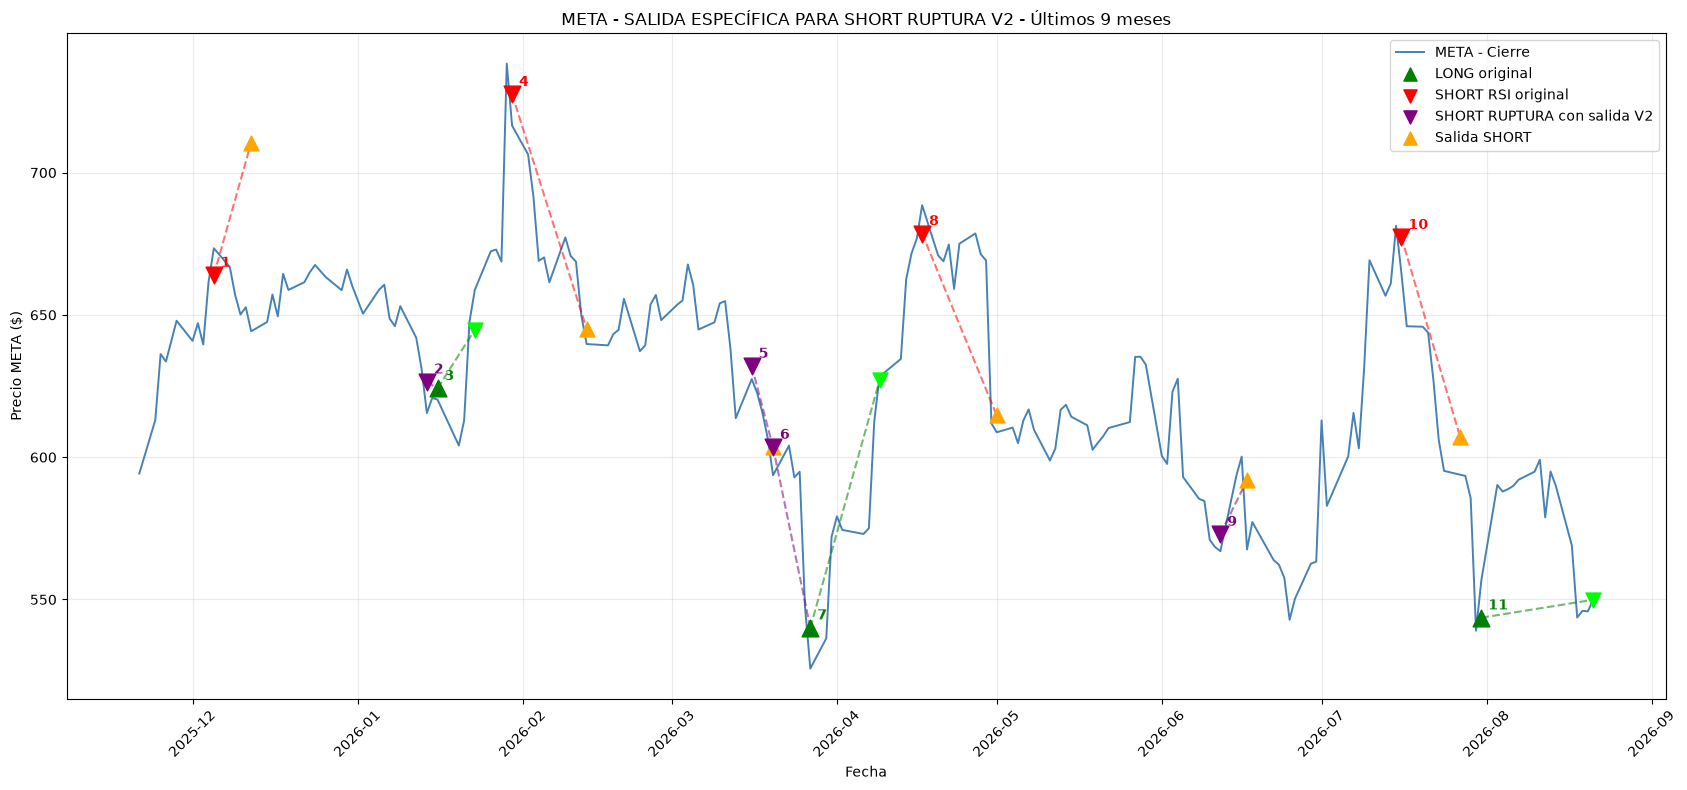

OPERACIONES V2 A 9 MESES


,Tipo,Sistema entrada,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad %,Motivo
0,SHORT,RSI > 70,2025-12-05 00:00:00,$664.00,2025-12-12 00:00:00,$710.48,-7.00%,STOP LOSS SHORT
1,SHORT,RUPTURA,2026-01-14 00:00:00,$626.50,2026-01-16 00:00:00,$624.18,+0.37%,PRIORIDAD A NUEVA ENTRADA ORIGINAL
2,LONG,RSI + BOLLINGER,2026-01-16 00:00:00,$624.18,2026-01-23 00:00:00,$644.77,+3.30%,SEÑAL SALIDA LONG
3,SHORT,RSI > 70,2026-01-30 00:00:00,$727.50,2026-02-13 00:00:00,$645.10,+11.33%,SEÑAL SALIDA SHORT
4,SHORT,RUPTURA,2026-03-16 00:00:00,$632.00,2026-03-20 00:00:00,$603.53,+4.50%,PRIORIDAD A NUEVA ENTRADA ORIGINAL
5,SHORT,RUPTURA,2026-03-20 00:00:00,$603.53,2026-03-27 00:00:00,$540.10,+10.51%,PRIORIDAD A NUEVA ENTRADA ORIGINAL
6,LONG,RSI + BOLLINGER,2026-03-27 00:00:00,$540.10,2026-04-09 00:00:00,$626.97,+16.08%,SEÑAL SALIDA LONG
7,SHORT,RSI > 70,2026-04-17 00:00:00,$678.60,2026-05-01 00:00:00,$614.69,+9.42%,SEÑAL SALIDA SHORT
8,SHORT,RUPTURA,2026-06-12 00:00:00,$572.95,2026-06-17 00:00:00,$592.00,-3.32%,DOS CIERRES SOBRE EMA10
9,SHORT,RSI > 70,2026-07-16 00:00:00,$677.28,2026-07-27 00:00:00,$607.22,+10.34%,SEÑAL SALIDA SHORT


In [6]:
# Único gráfico: V2 a 9 meses
periodo, r = resultados[9]['datos'], resultados[9]['V2']
fig,ax=plt.subplots(figsize=(17,8))
ax.plot(periodo.index,periodo['Close'],lw=1.4,color='steelblue',label='META - Cierre')
for numero,op in enumerate(r['Operaciones'],1):
    if op['Tipo']=='LONG': color,marker='green','^'
    elif op['Sistema entrada']=='RUPTURA': color,marker='purple','v'
    else: color,marker='red','v'
    ax.scatter(op['Entrada'],op['Precio entrada'],color=color,marker=marker,s=145,zorder=6)
    ax.scatter(op['Salida'],op['Precio salida'],color='lime' if op['Tipo']=='LONG' else 'orange',
               marker='v' if op['Tipo']=='LONG' else '^',s=115,zorder=6)
    ax.plot([op['Entrada'],op['Salida']],[op['Precio entrada'],op['Precio salida']],color=color,ls='--',alpha=.55)
    ax.annotate(str(numero),(op['Entrada'],op['Precio entrada']),xytext=(5,6),textcoords='offset points',color=color,weight='bold')
ax.scatter([],[],color='green',marker='^',s=90,label='LONG original')
ax.scatter([],[],color='red',marker='v',s=90,label='SHORT RSI original')
ax.scatter([],[],color='purple',marker='v',s=90,label='SHORT RUPTURA con salida V2')
ax.scatter([],[],color='orange',marker='^',s=90,label='Salida SHORT')
ax.set_title('META - SALIDA ESPECÍFICA PARA SHORT RUPTURA V2 - Últimos 9 meses')
ax.set_xlabel('Fecha');ax.set_ylabel('Precio META ($)');ax.grid(alpha=.25);ax.legend(loc='best')
plt.xticks(rotation=45);plt.tight_layout()
display(fig);plt.close(fig)
print('OPERACIONES V2 A 9 MESES')
display(pd.DataFrame(r['Operaciones']).style.format({'Precio entrada':'${:,.2f}',
    'Precio salida':'${:,.2f}','Rentabilidad %':'{:+.2f}%'}))